# Therapeutic Mapping: intervention on $\beta$ (elongation of $PrP^{Sc}$).

## Motivation:

The **Morris** sensitivity analysis identified $\beta$ (the elongation rate of $PrP^{Sc}$) as the **most sensitive parameter** of the model (combined sensitivity $\approx 0.84$). The fact that $\beta$ dominates the dynamics makes it the **natural therapeutic target**: if small variations of $\beta$ produce large changes in the trajectory, then a drug that reduces $\beta$ should have a disproportionately large clinical effect.

The goal here is therefore to **quantify that intuition in clinical units (days of onset delay)**. Instead of optimizing a treatment, we first **map the design terrain**: systematically sweeping the two most basic clinical decision axes and measuring how the disease onset changes.

## Pharmacodynamic model

An elongation inhibitor (e.g. an anti-PrP antibody or an active immunization that blocks the addition of monomers to the fiber ends) reduces the **effective** $\beta$:

$$\beta_{\text{eff}}(t) = \beta \cdot (1 - E), \qquad t \geq t_{\text{start}}$$

- **$E \in [0,1]$** — drug *efficacy* ($E=0$: no effect; $E=1$: total blockade of elongation).
- **$t_{\text{start}}$** — day on which treatment begins (allows studying the *therapeutic window*).

> **Assumption:** modeling the drug as a constant reduction of $\beta$ is a pharmacodynamic simplification (it assumes constant occupancy/effect from $t_{\text{start}}$, with no pharmacokinetics).

## What this notebook produces:

1. A **2D map** of onset-delay days over the $E \times t_{\text{start}}$ grid.
2. The critical efficacy (*$E^*$*) required to suppress the disease within the animal's lifespan.
3. The **therapeutic window**: how the benefit depends on starting early.

## 0. Dependencies and imports:

In [ ]:
!pip install casadi

import numpy as np
import matplotlib.pyplot as plt
from casadi import MX, vertcat, exp, integrator
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 7.6 MB/s eta 0:00:00


## 1. Configuration and model

We use the same 7-state `model_prion_v2` `[C, B, y, z, R, L, q]` with 20 parameters used in the calibration.

In [ ]:
def model_prion_v2(x, p):
    C, B, y, z, R, L, q = x[0], x[1], x[2], x[3], x[4], x[5], x[6]
    e, d, j1, j2, X_rec         = p[0], p[1], p[2], p[3], p[4]
    beta, a, b, n, f            = p[5], p[6], p[7], p[8], p[9]
    k1, k2                      = p[10], p[11]
    clear_L, trans_L, syn, c_q  = p[12], p[13], p[14], p[15]
    h_R, R_c_frac, z_sat, m_hill = p[16], p[17], p[18], p[19]

    free_receptors = X_rec - B - R
    F1 = (beta * C * y) * (f / (f + z))                       # elongation (Masel) — depends on beta
    R_c = R_c_frac * X_rec
    sigma_R = 1.0 / (1.0 + exp(-h_R * (R - R_c)))             # membrane switch (Payne)
    sigma_z = z**m_hill / (z_sat**m_hill + z**m_hill)         # mass switch (Hill, Sandberg)
    F2 = trans_L * z * C * (sigma_R * sigma_z) + syn * z * C * L   # PrPL generation (Cabrera-Álvarez)

    dB = j1*free_receptors*C - j2*B - d*B
    dR = k1*free_receptors*z - k2*R - a*R
    dC = e - j1*free_receptors*C + j2*B - F1 + n*(n-1)*b*y - F2
    dy = b*z - (2*n-1)*b*y - k1*free_receptors*y + k2*(y/(z+1e-9))*R - a*y
    dz = F1 - n*(n-1)*b*y - k1*free_receptors*z + k2*R - a*z
    dL = F2 - clear_L*L
    dq = c_q*L*(1-q)
    return vertcat(dC, dB, dy, dz, dR, dL, dq)

# Symbols and DAE (the same object is reused for all integrators)
x_sym = MX.sym('x', 7)
p_sym = MX.sym('p', 20)
dae = {'x': x_sym, 'p': p_sym, 'ode': model_prion_v2(x_sym, p_sym)}

## 2. Calibrated parameters
> **We must use `p_calibrated`**. Index **5 is `beta`**, which is the parameter this notebook intervenes on. Everything else is computed relative to the baseline, so the map is robust to the absolute value of `beta`.

In [ ]:
# Calibrated vector (WT, Prnp+/+).  Index 5 = beta (therapeutic target).
p_calibrated = np.array([
    1.68483e-02,          # [0]  e        PrPC synthesis [Done]
    1.26026760e-01,       # [1]  Delta_B  Surface PrPC degradation
    2.14752e-01,          # [2]  j1       PrPC → receptor [Done]
    1.27508e-01,          # [3]  j2       PrPC ← receptor [Done]
    1.68750e-02,          # [4]  X_rec    Total receptors
    6.70138e+03,          # [5]  beta     Elongation -> THERAPEUTIC TARGET [Done]
    7.22033e-02,          # [6]  Delta_R  PrPSc degradation [Done]
    4.37536e-05,          # [7]  b        Fragmentation
    6.0,                  # [8]  n        Minimum stable nucleus
    3.17502e-03,          # [9]  f        Elongation critical mass [Done]
    8.34073e+00,          # [10] k1       PrPSc → receptor [Done]
    5.84697e-04,          # [11] k2       PrPSc ← receptor [Done]
    1.16510e-03,          # [12] Delta_L  PrPL clearance
    2.85169e-02,          # [13] Lambda_L Basal transformation to PrPL (FIXED after Morris and SVD)
    1.00000e-04,          # [14] Lambda_S      Synergistic autocatalysis
    3.28191e-01,          # [15] c_q      Clinical damage accumulation [Done]
    100.0,                # [16] h_R      Membrane switch slope
    0.4,                  # [17] R_c      Receptor threshold fraction
    1.06053e-01,          # [18] z_sat    PrPSc plateau mass [Done]
    5.0,                  # [19] m_hill   Hill order
])
IDX_BETA = 5

# WT initial condition: [C, B, y, z, R, L, q]
x0 = np.array([0.0169, 0.008, 1e-8, 1e-6, 0.0, 1e-8, 0.0])

# Experiment / sweep constants
Q_THR       = 0.5     # clinical onset threshold (q = 0.5)
HORIZON     = 730.0   # horizon ≈ mouse lifespan (2 years); onset > HORIZON = "suppressed within lifespan"
T_CLIN_OBS  = 137.0   # observed WT clinical onset (Sandberg 2011), reference only

print(f"calibrated beta = {p_calibrated[IDX_BETA]:.4e} 1/(µM·day)")

calibrated beta = 6.7014e+03 1/(µM·day)


## 3. Intervention simulator — two-segment integration:

The treatment changes $\beta$ at an instant $t_{\text{start}}$. Rather than introducing a smooth time function (which would add numerical stiffness), the DAE is integrated in **two exact segments**:

1. **Pre-treatment segment** $[0,\, t_{\text{start}}]$ with full $\beta$ $\Rightarrow$ the state $\mathbf{x}(t_{\text{start}})$ is obtained.
2. **Treated segment** $[t_{\text{start}},\, t_{\text{HORIZON}} = 730\ \text{days}]$ with $\beta_{\text{eff}} = \beta(1-E)$, **starting from $\mathbf{x}(t_{\text{start}})$**.

**Concrete example: cell (E=0.6, t_start=40)**

- Days 0 → 40: integrated with β = 1293.58 (calibrated). The 7 states evolve, q is near zero. The state x(40) is stored.
- Days 40 → 730: integrated with β = 1293.58 × (1 − 0.6) = 517.4, starting from x(40).

The 7 states keep evolving, now with reduced elongation. At some point *q* crosses 0.5 → that is the onset (≈ 150 d in the example, +15 relative to the baseline of 135). Each of the 2025 grid cells does this with its own pair (E, $t_{start}$). Each cell is an independent simulation.

In [ ]:
def _cross_time(q, tg):
    # Instant at which q crosses Q_THR (interpolated). Returns None if it does not cross.
    if (q >= Q_THR).any():
        k = int(np.argmax(q >= Q_THR))
        if k == 0:
            return tg[0]
        return float(np.interp(Q_THR, [q[k-1], q[k]], [tg[k-1], tg[k]]))
    return None

def onset_with_treatment(E, t_start, horizon=HORIZON, npts=400, return_traj=False):
    # Onset (q=0.5 crossing) under beta_eff = beta*(1-E) applied from t_start.
    # return_traj=True also returns (t, q) concatenated for plotting.
    # Segment 1: no treatment
    if t_start > 1e-6:
        tg1 = np.linspace(0.0, t_start, max(int(npts * t_start / horizon), 20))
        X1 = integrator('F', 'idas', dae, 0.0, tg1,
                        {'reltol': 1e-7, 'abstol': 1e-10})(x0=x0, p=p_calibrated)['xf'].full()
        q1, x_switch = X1[6, :], X1[:, -1]
        tc = _cross_time(q1, tg1)              # did it already fall ill before treatment?
        if tc is not None:
            return (tc, (tg1, q1)) if return_traj else tc
    else:
        tg1, q1, x_switch = np.array([0.0]), np.array([x0[6]]), x0

    # Segment 2: treated (reduced beta)
    p_tr = p_calibrated.copy()
    p_tr[IDX_BETA] = p_calibrated[IDX_BETA] * (1.0 - E)
    tg2 = np.linspace(t_start, horizon, npts)
    X2 = integrator('F', 'idas', dae, t_start, tg2,
                    {'reltol': 1e-7, 'abstol': 1e-10})(x0=x_switch, p=p_tr)['xf'].full()
    q2 = X2[6, :]
    tc = _cross_time(q2, tg2)
    onset = tc if tc is not None else np.inf

    if return_traj:
        t_full = np.concatenate([tg1, tg2]); q_full = np.concatenate([q1, q2])
        return onset, (t_full, q_full)
    return onset

print("Intervention simulator ready.")

Intervention simulator ready.


## 4. Baseline (no treatment)

Model onset with no intervention ($E=0$). It should match the calibration target ($\approx 137$ days, Sandberg 2011). All subsequent delays are measured **relative** to this value.

In [ ]:
onset_base = onset_with_treatment(0.0, 0.0)
print(f"Baseline onset (no treatment) : {onset_base:6.1f} days")
print(f"Observed WT onset (Sandberg) : {T_CLIN_OBS:6.1f} days  (reference)")
print(f"Deviation                    : {onset_base - T_CLIN_OBS:+.1f} days")

Baseline onset (no treatment) :  139.2 days
Observed WT onset (Sandberg) :  137.0 days  (reference)
Deviation                    : +2.2 days


## 5. Terrain sweep ($E \times t_{\text{start}}$)

A grid of efficacies $E$ and start times $t_{\text{start}}$ is traversed, recording the onset in each cell. For efficiency, the **pre-treatment segment is computed only once per $t_{\text{start}}$** (it does not depend on $E$) and reused for all efficacies. The full sweep takes ~5 s.

In [ ]:
NE, NT = 45, 45                                   # grid resolution
E_grid      = np.linspace(0.0, 1.0, NE)           # drug efficacy
tstart_grid = np.linspace(0.0, 130.0, NT)         # treatment start day

t0 = time.time()

# Pre-computation: state at each t_start (untreated segment, common to all E)
x_at_start = {}
for ts in tstart_grid:
    if ts > 1e-6:
        tg = np.linspace(0.0, ts, max(int(400 * ts / HORIZON), 20))
        Xp = integrator('F', 'idas', dae, 0.0, tg,
                        {'reltol': 1e-7, 'abstol': 1e-10})(x0=x0, p=p_calibrated)['xf'].full()
        x_at_start[ts] = Xp[:, -1]
    else:
        x_at_start[ts] = x0

# Sweep of the treated segment
Onset = np.full((NT, NE), np.nan)
for i, ts in enumerate(tstart_grid):
    tg2 = np.linspace(ts, HORIZON, 400)
    I2 = integrator('F', 'idas', dae, ts, tg2, {'reltol': 1e-7, 'abstol': 1e-10})
    for jx, E in enumerate(E_grid):
        p_tr = p_calibrated.copy()
        p_tr[IDX_BETA] = p_calibrated[IDX_BETA] * (1.0 - E)
        q = I2(x0=x_at_start[ts], p=p_tr)['xf'].full()[6, :]
        tc = _cross_time(q, tg2)
        Onset[i, jx] = tc if tc is not None else np.inf

Delay = Onset - onset_base                         # delay days relative to baseline
n_suppress = int(np.sum(~np.isfinite(Onset)))
print(f"{NT}×{NE} grid computed in {time.time()-t0:.1f} s")
print(f"Maximum delay (finite): {np.nanmax(Delay[np.isfinite(Delay)]):.0f} days")
print(f"Cells with suppression (onset > {HORIZON:.0f} d): {n_suppress}/{NT*NE}")

45×45 grid computed in 10.7 s
Maximum delay (finite): 590 days
Cells with suppression (onset > 730 d): 75/2025


## 6. Onset-delay map

Each point on the map answers: *if the drug has efficacy $E$ and treatment starts on day $t_{\text{start}}$, by how many days is the disease delayed?*. The contour lines mark clinically relevant delays; the gray region (top left) is where the disease **does not appear within the animal's lifespan**.

- For each E in [0.0, 0.02, 0.04, ..., 1.0]        (45 values)

- For each t_start in [0, 3, 6, ..., 130]      (45 values)

- Run a simulation with that (E, $t_{start}$)

- Record the onset

That is 45 × 45 = 2025 independent simulations. Each one yields a point of the map.

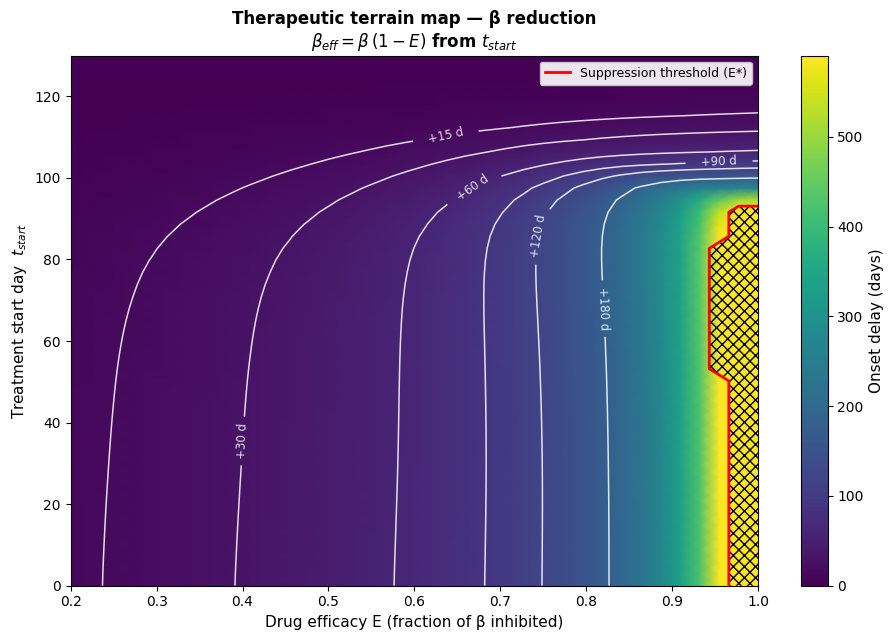

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

# onset=inf are encoded with the maximum finite delay → continuous color
delay_max_finite = np.nanmax(Delay[np.isfinite(Delay)])
Delay_plot = np.where(np.isfinite(Delay), Delay, delay_max_finite)

pcm = ax.pcolormesh(E_grid, tstart_grid, Delay_plot, cmap='viridis', shading='gouraud')
cbar = fig.colorbar(pcm, ax=ax); cbar.set_label('Onset delay (days)', fontsize=11)

# Delay contour lines
levels = [15, 30, 60, 90, 120, 180]
cs = ax.contour(E_grid, tstart_grid, Delay_plot, levels=levels,
                colors='white', linewidths=1.1, alpha=0.85)
ax.clabel(cs, fmt='+%d d', fontsize=8.5)

# Suppression region (onset > horizon)
supp = ~np.isfinite(Onset)
ax.contourf(E_grid, tstart_grid, supp.astype(float), levels=[0.5, 1.5],
            colors='none', hatches=['xxx'])
ax.contour(E_grid, tstart_grid, supp.astype(float), levels=[0.5], colors='red', linewidths=2)
ax.plot([], [], color='red', lw=2, label='Suppression threshold (E*)')

ax.set_xlabel('Drug efficacy E (fraction of β inhibited)', fontsize=11)
ax.set_ylabel('Treatment start day  $t_{start}$', fontsize=11)
ax.set_title('Therapeutic terrain map — β reduction\n'
             r'$\beta_{eff}=\beta\,(1-E)$ from $t_{start}$',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.2, 1.0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout(); plt.show()

The region where the treatment suppresses the disease within the 730-day horizon (i.e., q(t) never crosses 0.5, so onset (start of the clinical phase) = ∞):

- Hatched (×××) = areas where, even with that (E, t_start) combination, the disease does not appear within the simulated window.
- Red border = the threshold E* that separates "the drug only delays" from "the drug suppresses".

## 7. Mechanism: clinical-damage trajectories $q(t)$

To see *why* the map has this shape, $q(t)$ trajectories are plotted under different scenarios. Reducing $\beta$ slows the accumulation of PrP$^{Sc}$, delaying the crossing of $z_{\text{sat}}$ that triggers the toxic Phase 2 and, with it, the growth of $q$.

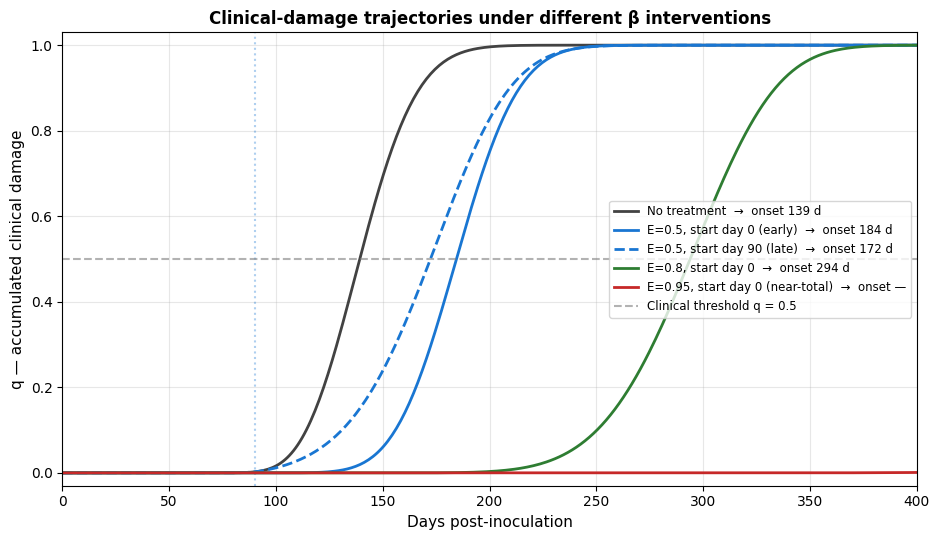

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))

scenarios = [
    (0.0, 0.0,  '#424242', '-',  'No treatment'),
    (0.5, 0.0,  '#1976D2', '-',  'E=0.5, start day 0 (early)'),
    (0.5, 90.0, '#1976D2', '--', 'E=0.5, start day 90 (late)'),
    (0.8, 0.0,  '#2E7D32', '-',  'E=0.8, start day 0'),
    (0.95, 0.0, '#C62828', '-',  'E=0.95, start day 0 (near-total)'),
]
for E, ts, c, ls, lab in scenarios:
    onset, (t, q) = onset_with_treatment(E, ts, horizon=400, return_traj=True)
    onset_txt = f'{onset:.0f} d' if np.isfinite(onset) else '—'
    ax.plot(t, q, color=c, ls=ls, lw=2, label=f'{lab}  →  onset {onset_txt}')
    if ts > 0:
        ax.axvline(ts, color=c, ls=':', alpha=0.35)

ax.axhline(Q_THR, color='gray', ls='--', alpha=0.6, label='Clinical threshold q = 0.5')
ax.set_xlabel('Days post-inoculation', fontsize=11)
ax.set_ylabel('q — accumulated clinical damage', fontsize=11)
ax.set_title('Clinical-damage trajectories under different β interventions', fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5, loc='center right'); ax.grid(alpha=0.3)
ax.set_xlim(0, 400); ax.set_ylim(-0.03, 1.03)
plt.tight_layout(); plt.show()

## 8. Critical efficacy E* and therapeutic window

Two quantitative readings of the map:

- **$E^*(t_{\text{start}})$**: the minimum efficacy required to suppress the disease within the horizon, as a function of when treatment starts. It is obtained by bisection over $E$ for each $t_{\text{start}}$.
- **Therapeutic window**: for a fixed efficacy, how much delay is achieved depending on the start day — it quantifies the cost of diagnosing/treating late.

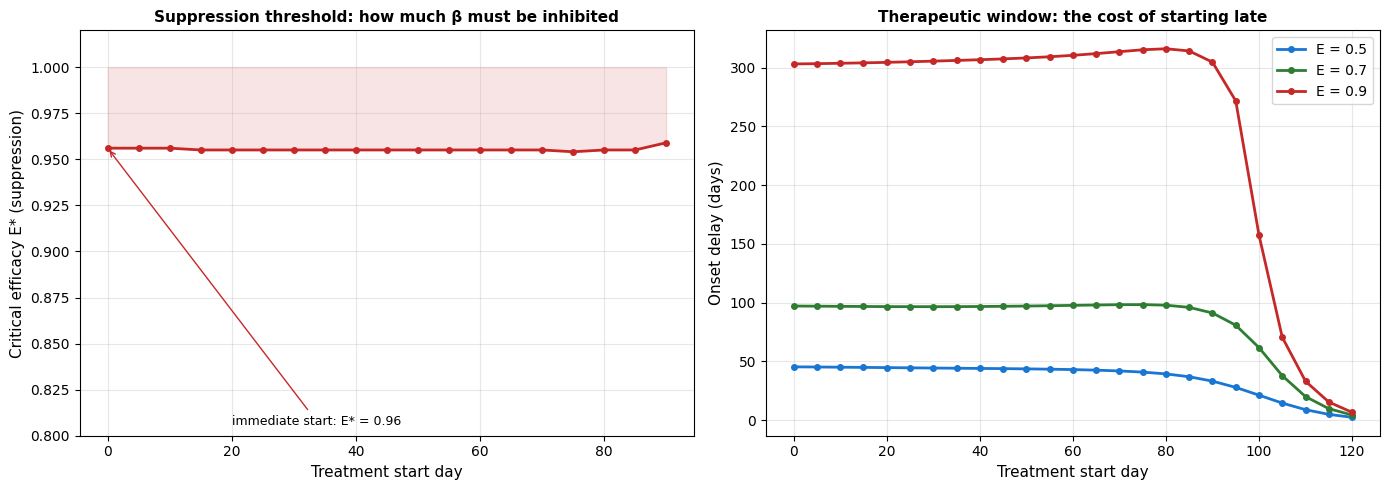

Suppression-threshold summary E*:
  t_start =   0 d  →  E* = 0.956
  t_start =  30 d  →  E* = 0.955
  t_start =  60 d  →  E* = 0.955
  t_start =  90 d  →  E* = 0.959


In [ ]:
# E* by bisection for each t_start
def E_critical(t_start, tol=1e-3):
    if not np.isfinite(onset_with_treatment(1.0, t_start)):   # even E=1 does not suppress
        lo, hi = 0.0, 1.0
        for _ in range(40):
            mid = (lo + hi) / 2
            if np.isfinite(onset_with_treatment(mid, t_start)): lo = mid
            else: hi = mid
            if hi - lo < tol: break
        return hi
    return np.nan   # not even total blockade suppresses → only delays

ts_scan = np.linspace(0.0, 120.0, 25)
Estar = np.array([E_critical(ts) for ts in ts_scan])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: E* vs t_start
ax1.plot(ts_scan, Estar, 'o-', color='#C62828', lw=2, ms=4)
ax1.fill_between(ts_scan, Estar, 1.0, alpha=0.12, color='#C62828')
ax1.set_xlabel('Treatment start day', fontsize=11)
ax1.set_ylabel('Critical efficacy E* (suppression)', fontsize=11)
ax1.set_title('Suppression threshold: how much β must be inhibited', fontsize=11, fontweight='bold')
ax1.grid(alpha=0.3); ax1.set_ylim(0.8, 1.02)
if np.isfinite(Estar[0]):
    ax1.annotate(f'immediate start: E* = {Estar[0]:.2f}', xy=(0, Estar[0]),
                 xytext=(20, Estar[0]-0.15), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='#C62828'))

# Panel B: therapeutic window (delay vs t_start for several E)
for E, c in [(0.5, '#1976D2'), (0.7, '#2E7D32'), (0.9, '#C62828')]:
    delays = []
    for ts in ts_scan:
        o = onset_with_treatment(E, ts)
        delays.append((o - onset_base) if np.isfinite(o) else np.nan)
    ax2.plot(ts_scan, delays, 'o-', color=c, lw=2, ms=4, label=f'E = {E}')
ax2.set_xlabel('Treatment start day', fontsize=11)
ax2.set_ylabel('Onset delay (days)', fontsize=11)
ax2.set_title('Therapeutic window: the cost of starting late', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Numerical summary
print("Suppression-threshold summary E*:")
for ts in [0, 30, 60, 90]:
    e = E_critical(float(ts))
    print(f"  t_start = {ts:3d} d  →  E* = {e:.3f}" if np.isfinite(e)
          else f"  t_start = {ts:3d} d  →  suppression impossible (not even with E=1)")